<a href="https://colab.research.google.com/github/denverkim/ALGORITHM/blob/main/ALGORITHM_LAB8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# 선형탐색
def linear(ds, key):
    for a in range(0, len(ds)):
        if key == ds[a]:
            return a
    return
dataset = [20, 50, 30, 10, 60, 40]
print(linear(dataset, 10))

3


In [7]:
# 이진탐색
def binary(ds, key):
    low = 0
    high = len(ds)-1
    while low <= high:
        mid = (low+high)//2
        if key == ds[mid]:
            return mid
        elif key < ds[mid]:
            high = mid-1
        else:
            low = mid+1
    return
dataset = [10, 20, 30, 40, 50]
print(binary(dataset, 20))

1


In [ ]:
# 날씨 웹사이트에 접근해서 정보를 스크래핑
import requests
from bs4 import BeautifulSoup

page = requests.get('http://forecast.weather.gov/MapClick.php?lat=37.7772&lon=-122.4168')
soup = BeautifulSoup(page.content)
print(soup.prettify())

In [39]:
# 날씨 정보 추출
temp_high = []
for t in soup.select('p.temp.temp-high'):
    temp_high.append(t.get_text().split(':')[1][:3].strip())

temp_low = []
for t in soup.select('p.temp.temp-low'):
    temp_low.append(t.get_text().split(':')[1][:3].strip())

period_name = []
for p in soup.select('p.period-name'):
    period_name.append(p.get_text().strip())

short_desc = []
for s in soup.select('p.short-desc'):
    short_desc.append(s.get_text().strip())

In [40]:
# 날씨 정보 전처리
temp_high = [int(t) for t in temp_high][:-1] # 마지막 온도 제거
temp_low = [int(t) for t in temp_low] # 숫자 데이터로 전환
period_name = [period_name[i] for i in range(0, len(period_name), 2)][:-1] # 한개씩 건너띄어서 저장
short_desc = [short_desc[i] for i in range(0, len(short_desc), 2)][:-1] # 하나씩 건너띄어서 저장

In [41]:
# 데이터 갯수 맞추기
len(temp_high), len(temp_low), len(period_name), len(short_desc)

(4, 4, 4, 4)

In [42]:
import pandas as pd

df = pd.DataFrame({'period_name': period_name,
                   'temp_high': temp_high,
                   'temp_low': temp_low,
                   'short_desc': short_desc})

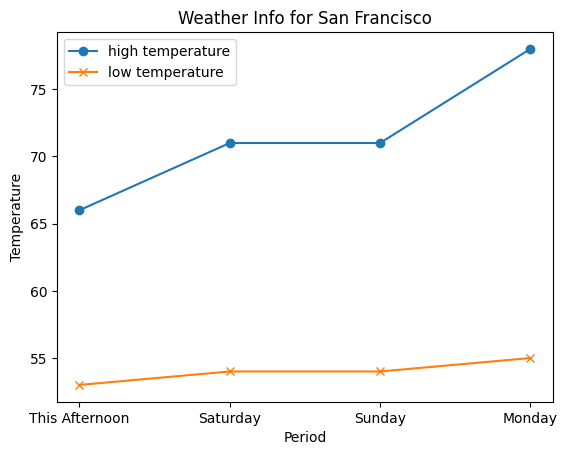

In [46]:
# 시각화
import matplotlib.pyplot as plt

plt.plot(df.period_name, df.temp_high, 'o-', label='high temperature')
plt.plot(df.period_name, df.temp_low, 'x-', label='low temperature')
plt.legend()
plt.title('Weather Info for San Francisco')
plt.xlabel('Period')
plt.ylabel('Temperature')
plt.show()